In [2]:
! pip install psycopg2-binary boto3

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 386.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 116.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.4/84.4 kB 231.5 MB/s eta 0:00:00


In [2]:
import psycopg2
import boto3
from psycopg2.extras import RealDictCursor
import json
import logging
from typing import List, Dict

In [3]:

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Database connection parameters for the Dockerized PostgreSQL
DB_CONFIG = {
    # 'dbname': 'clinmatch_aact',
    'dbname': 'clinmatch_aact',
    'user': 'postgres',
    'password': 'password',  # Matches the password set in Docker
    'host': 'localhost',     # Container port mapped to host
    'port': '5432'           # Default PostgreSQL port mapped to host
}

In [4]:
def connect_to_db():
    """Establishes a connection to the PostgreSQL database in the Docker container."""
    try:
        conn = psycopg2.connect(**DB_CONFIG)
        logger.info("Successfully connected to the database")
        return conn
    except Exception as e:
        logger.error(f"Failed to connect to the database: {e}")
        raise


In [ ]:
query = f"""
    SELECT 
       s.nct_id,
       s.official_title,
       s.brief_title,
       s.updated_at,
       s.overall_status,
       dd.description AS detailed_description,
       bs.description AS brief_summary,
       e.criteria,
       ARRAY_AGG(bc.downcase_mesh_term) AS mesh_terms
   FROM studies s
   LEFT JOIN detailed_descriptions dd ON s.nct_id = dd.nct_id
   LEFT JOIN brief_summaries bs ON s.nct_id = bs.nct_id
   LEFT JOIN eligibilities e ON s.nct_id = e.nct_id
   LEFT JOIN browse_conditions bc ON s.nct_id = bc.nct_id
#    WHERE s.phase IN ('PHASE1', 'PHASE1/PHASE2', 'PHASE2', 'PHASE2/PHASE3', 'PHASE3', 'PHASE4')
   WHERE s.phase IN ('PHASE1')
     AND s.study_type = 'INTERVENTIONAL'
     AND s.overall_status IN ('ACTIVE_NOT_RECRUITING', 'NOT_YET_RECRUITING', 'RECRUITING')
   GROUP BY 
       s.nct_id, s.official_title, s.brief_title, s.updated_at, s.overall_status,
       dd.description, bs.description, e.criteria
   ORDER BY s.nct_id;
    """

In [5]:
def fetch_study_data(conn, status='ACTIVE_NOT_RECRUITING') -> List[Dict]:
    """Fetches clinical trial data from the database."""
    query = f"""
    SELECT 
       s.nct_id,
       s.official_title,
       s.brief_title,
       s.updated_at,
       s.overall_status,
       dd.description AS detailed_description,
       bs.description AS brief_summary,
       e.criteria,
       ARRAY_AGG(bc.downcase_mesh_term) AS mesh_terms
   FROM studies s
   LEFT JOIN detailed_descriptions dd ON s.nct_id = dd.nct_id
   LEFT JOIN brief_summaries bs ON s.nct_id = bs.nct_id
   LEFT JOIN eligibilities e ON s.nct_id = e.nct_id
   LEFT JOIN browse_conditions bc ON s.nct_id = bc.nct_id
   WHERE s.phase IN ('PHASE1', 'PHASE1/PHASE2', 'PHASE2', 'PHASE2/PHASE3', 'PHASE3', 'PHASE4')
     AND s.study_type = 'INTERVENTIONAL'
     AND s.overall_status IN ('ACTIVE_NOT_RECRUITING', 'NOT_YET_RECRUITING', 'RECRUITING')
   GROUP BY 
       s.nct_id, s.official_title, s.brief_title, s.updated_at, s.overall_status,
       dd.description, bs.description, e.criteria
   ORDER BY s.nct_id;
    """
    try:
        cursor = conn.cursor(cursor_factory=RealDictCursor)
        cursor.execute(query)
        results = cursor.fetchall()
        cursor.close()
        logger.info(f"Fetched {len(results)} records from the database")
        return results
    except Exception as e:
        logger.error(f"Error executing query: {e}")
        raise

In [6]:
def merge_data_to_text(record: Dict) -> str:
    """Merges a record's fields into a single text string."""
    nct_id = record['nct_id'] or ''
    official_title = record['official_title'] or ''
    brief_title = record['brief_title'] or ''
    updated_at = str(record['updated_at']) if record['updated_at'] else ''
    detailed_description = record['detailed_description'] or ''
    brief_summary = record['brief_summary'] or ''
    criteria = record['criteria'] or ''
    mesh_terms = ', '.join([term for term in (record['mesh_terms'] or []) if term]) or ''

    text = (
        f"NCT ID: {nct_id}\n"
        f"Official Title: {official_title}\n"
        f"Brief Title: {brief_title}\n"
        f"Updated At: {updated_at}\n"
        f"Detailed Description: {detailed_description}\n"
        f"Brief Summary: {brief_summary}\n"
        f"Criteria: {criteria}\n"
        f"Mesh Terms: {mesh_terms}\n"
        "----------------------------------------\n"
    )
    return text

In [8]:
status_all = ["ACTIVE_NOT_RECRUITING",
 "APPROVED_FOR_MARKETING",
 "AVAILABLE",
 "COMPLETED",
 "ENROLLING_BY_INVITATION",
 "NO_LONGER_AVAILABLE",
 "NOT_YET_RECRUITING",
 "RECRUITING",
 "SUSPENDED",
 "TEMPORARILY_NOT_AVAILABLE",
 "TERMINATED",
 "UNKNOWN",
 "WITHDRAWN",
 "WITHHELD"]

In [17]:
# 20250408
conn = connect_to_db()
records = fetch_study_data(conn)

2025-04-24 15:01:57,642 - INFO - Successfully connected to the database
2025-04-24 15:02:01,964 - INFO - Fetched 34073 records from the database


In [6]:
# 20250423
conn = connect_to_db()
records = fetch_study_data(conn)

2025-04-25 15:24:59,751 - INFO - Successfully connected to the database
2025-04-25 15:25:03,961 - INFO - Fetched 34272 records from the database


In [7]:
# 20250425
conn = connect_to_db()
records = fetch_study_data(conn)

2025-04-25 16:49:05,382 - INFO - Successfully connected to the database
2025-04-25 16:49:09,618 - INFO - Fetched 34310 records from the database


In [24]:
records_count = {}
conn = connect_to_db()
for status in status_all: 
    records = fetch_study_data(conn, status)
    records_count[status] = len(records)

2025-04-14 16:46:30,185 - INFO - Successfully connected to the database
2025-04-14 16:46:32,245 - INFO - Fetched 20618 records from the database
2025-04-14 16:46:32,303 - INFO - Fetched 220 records from the database
2025-04-14 16:46:32,375 - INFO - Fetched 258 records from the database
2025-04-14 16:46:50,584 - INFO - Fetched 291722 records from the database
2025-04-14 16:46:51,024 - INFO - Fetched 4446 records from the database
2025-04-14 16:46:51,461 - INFO - Fetched 483 records from the database
2025-04-14 16:46:53,085 - INFO - Fetched 23197 records from the database
2025-04-14 16:47:00,738 - INFO - Fetched 66274 records from the database
2025-04-14 16:47:00,972 - INFO - Fetched 1649 records from the database
2025-04-14 16:47:01,064 - INFO - Fetched 25 records from the database
2025-04-14 16:47:03,525 - INFO - Fetched 31009 records from the database
2025-04-14 16:47:09,741 - INFO - Fetched 77343 records from the database
2025-04-14 16:47:11,136 - INFO - Fetched 15068 records from th

In [25]:
records_count

{'ACTIVE_NOT_RECRUITING': 20618,
 'APPROVED_FOR_MARKETING': 220,
 'AVAILABLE': 258,
 'COMPLETED': 291722,
 'ENROLLING_BY_INVITATION': 4446,
 'NO_LONGER_AVAILABLE': 483,
 'NOT_YET_RECRUITING': 23197,
 'RECRUITING': 66274,
 'SUSPENDED': 1649,
 'TEMPORARILY_NOT_AVAILABLE': 25,
 'TERMINATED': 31009,
 'UNKNOWN': 77343,
 'WITHDRAWN': 15068,
 'WITHHELD': 921}

| Status                          | Count    |
|---------------------------------|----------|
| COMPLETED                       | 291,722  |
| RECRUITING                       | 66,274   |
| UNKNOWN                          | 77,343   |
| TERMINATED                       | 31,009   |
| ACTIVE_NOT_RECRUITING            | 20,618   |
| NOT_YET_RECRUITING               | 23,197   |
| WITHDRAWN                        | 15,068   |
| ENROLLING_BY_INVITATION          | 4,446    |
| SUSPENDED                        | 1,649    |
| APPROVED_FOR_MARKETING           | 220      |
| AVAILABLE                        | 258      |
| NO_LONGER_AVAILABLE              | 483      |
| WITHHELD                         | 921      |
| TEMPORARILY_NOT_AVAILABLE        | 25       |

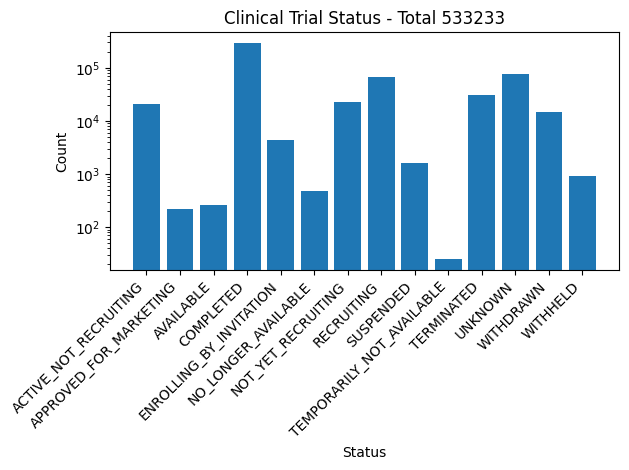

In [33]:
import matplotlib.pyplot as plt

plt.bar(records_count.keys(), records_count.values())
plt.xlabel('Status')
plt.ylabel('Count')
plt.yscale('log') 
plt.title(f'Clinical Trial Status - Total {sum(records_count.values())}')
# right-align x-ticks
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [38]:
records[0]

RealDictRow([('nct_id', 'NCT00000102'),
             ('official_title', None),
             ('brief_title',
              'Congenital Adrenal Hyperplasia: Calcium Channels as Therapeutic Targets'),
             ('updated_at', datetime.datetime(2025, 4, 6, 18, 1, 47, 260213)),
             ('overall_status', 'COMPLETED'),
             ('detailed_description',
              'This protocol is designed to assess both acute and chronic effects of the calcium channel antagonist, nifedipine, on the hypothalamic-pituitary-adrenal axis in patients with congenital adrenal hyperplasia. The multicenter trial is composed of two phases and will involve a double-blind, placebo-controlled parallel design. The goal of Phase I is to examine the ability of nifedipine vs. placebo to decrease adrenocorticotropic hormone (ACTH) levels, as well as to begin to assess the dose-dependency of nifedipine effects. The goal of Phase II is to evaluate the long-term effects of nifedipine; that is, can attenuation of 

In [19]:
records[0].get('overall_status')

'COMPLETED'

In [20]:
merged_texts = [merge_data_to_text(record) for record in records[:5]]

In [21]:
merged_texts[0]

'NCT ID: NCT00000102\nOfficial Title: \nBrief Title: Congenital Adrenal Hyperplasia: Calcium Channels as Therapeutic Targets\nUpdated At: 2025-04-06 18:01:47.260213\nDetailed Description: This protocol is designed to assess both acute and chronic effects of the calcium channel antagonist, nifedipine, on the hypothalamic-pituitary-adrenal axis in patients with congenital adrenal hyperplasia. The multicenter trial is composed of two phases and will involve a double-blind, placebo-controlled parallel design. The goal of Phase I is to examine the ability of nifedipine vs. placebo to decrease adrenocorticotropic hormone (ACTH) levels, as well as to begin to assess the dose-dependency of nifedipine effects. The goal of Phase II is to evaluate the long-term effects of nifedipine; that is, can attenuation of ACTH release by nifedipine permit a decrease in the dosage of glucocorticoid needed to suppress the HPA axis? Such a decrease would, in turn, reduce the deleterious effects of glucocortico

gene: hgnc
mycancergeno.gov

In [43]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [44]:

# AWS Lambda function details (replace with your own)
LAMBDA_REGION = 'ap-east-1'  # Your AWS region
LAMBDA_FUNCTION_NAME = 'clinmatch-dev-metamapParser'  # Your Lambda function name

def invoke_lambda(payload: Dict) -> Dict:
    """Invokes the AWS Lambda function with the given payload."""
    try:
        lambda_client = boto3.Session(aws_access_key_id=os.getenv('AWS_ACCESS_KEY_ID'), aws_secret_access_key=os.getenv('AWS_SECRET_ACCESS_KEY')).client('lambda', region_name=LAMBDA_REGION, )
        response = lambda_client.invoke(
            FunctionName=LAMBDA_FUNCTION_NAME,
            InvocationType='RequestResponse',
            Payload=json.dumps(payload)
        )
        response_payload = json.loads(response['Payload'].read().decode('utf-8'))
        logger.info("Successfully invoked Lambda function")
        return response_payload
    except Exception as e:
        logger.error(f"Error invoking Lambda function: {e}")
        raise


In [28]:
payload = {'text': merged_texts[0]}
result = invoke_lambda(payload)

2025-04-14 15:10:14,718 - INFO - Successfully invoked Lambda function


In [32]:
len(result['result'])

47

In [45]:
import pandas as pd

In [46]:
df_cancer_snomed_ct_tree = pd.read_json('./Data/SNOMED_CT_TREE.json')

In [35]:
from tqdm import tqdm

cui_df_cancer_snomed_ct_tree = [cui for cui in list(df_cancer_snomed_ct_tree['cui'])]
cui_df_cancer_snomed_ct_tree = set(cui_df_cancer_snomed_ct_tree)

for metamap_result in tqdm(result['result']): 
    metamap_result['onco_tag'] = metamap_result['cui'] in cui_df_cancer_snomed_ct_tree

100%|██████████| 47/47 [00:00<00:00, 880054.86it/s]


In [36]:
df = pd.DataFrame(result['result'])

In [37]:
df.head()

,cui,name,group,type,sources,matchedtext,start,length,onco_tag
0,C0001627,Congenital adrenal hyperplasia,disease,dsyn,"[LNC, MTH, CSP, ICD10CM, MSH, HPO, OMIM, CHV, ...",Congenital Adrenal Hyperplasia,50.0,30.0,False
1,C0006685,Calcium Channel,drug,bacs,"[MTH, CHV, CSP, MSH, NLMSubSyn, NCI, LCH_NW, AOD]",Calcium Channels,82.0,16.0,False
2,C0087111,Therapeutic procedure,drug,topp,"[MTH, LNC, CSP, MSH, NLMSubSyn, AOT, HL7V2.5, ...",Therapeutic,102.0,11.0,False
3,C0231491,Antagonist muscle action,disease,ortf,"[MTH, CHV, SNMI, SNM, UWDA, SNOMEDCT_US, FMA]",antagonist,273.0,10.0,False
4,C4721408,Substance with receptor antagonist mechanism o...,drug,phsu,"[MTH, NCI, SNOMEDCT_US]",antagonist,273.0,10.0,False


In [ ]:
import boto3
import logging
from botocore.exceptions import ClientError

DYNAMODB_TABLE_NAME = 'clinmatch-AACT-metamap'
AWS_REGION = 'ap-east-1'

dynamodb = boto3.Session(aws_access_key_id=os.getenv('AWS_ACCESS_KEY_ID'), aws_secret_access_key=os.getenv('AWS_SECRET_ACCESS_KEY')).resource('dynamodb', region_name=AWS_REGION)

def write_to_dynamodb(nct_id: str, updated_at: str, lambda_result: Dict):
    """Writes the Lambda result to DynamoDB along with nct_id and updated_at."""
    try:
        
        table = dynamodb.Table(DYNAMODB_TABLE_NAME)

        # Ensure updated_at is a string
        updated_at_str = str(updated_at)

        # Prepare the item to write
        item = {
            'nct_id': nct_id,
            'updated_at': updated_at_str,
            'lambda_result': lambda_result
        }

        # Write to DynamoDB
        table.put_item(Item=item)
        logger.info(f"Successfully wrote data for nct_id: {nct_id} to DynamoDB")
        
    except ClientError as e:
        logger.error(f"Error writing to DynamoDB: {e}")
        raise

In [223]:
dir = '/home/stevenhuang/Documents/clinmatch/clinmatch_AACT/failed_ids_phase1.txt'
with open(dir, 'r') as f:
    failed_ids = f.readlines()
failed_ids = [x.strip() for x in failed_ids]

In [9]:
query = f"""
    SELECT 
       s.nct_id,
       s.official_title,
       s.brief_title,
       s.updated_at,
       s.overall_status,
       dd.description AS detailed_description,
       bs.description AS brief_summary,
       e.criteria,
       ARRAY_AGG(bc.downcase_mesh_term) AS mesh_terms
   FROM studies s
   LEFT JOIN detailed_descriptions dd ON s.nct_id = dd.nct_id
   LEFT JOIN brief_summaries bs ON s.nct_id = bs.nct_id
   LEFT JOIN eligibilities e ON s.nct_id = e.nct_id
   LEFT JOIN browse_conditions bc ON s.nct_id = bc.nct_id
   WHERE s.phase IN ('PHASE1', 'PHASE1/PHASE2', 'PHASE2', 'PHASE2/PHASE3', 'PHASE3', 'PHASE4')
     AND s.study_type = 'INTERVENTIONAL'
     AND s.last_update_posted_date > '2025-04-09'
   GROUP BY 
       s.nct_id, s.official_title, s.brief_title, s.updated_at, s.overall_status,
       dd.description, bs.description, e.criteria
   ORDER BY s.updated_at;
    """
try:
    cursor = conn.cursor(cursor_factory=RealDictCursor)
    cursor.execute(query)
    results = cursor.fetchall()
    cursor.close()
    logger.info(f"Fetched {len(results)} records from the database")
except Exception as e:
    logger.error(f"Error executing query: {e}")
    raise

2025-04-25 17:04:30,473 - INFO - Fetched 4094 records from the database


In [8]:
query = f"""
    SELECT 
       s.nct_id,
       s.official_title,
       s.brief_title,
       s.updated_at,
       s.overall_status,
       dd.description AS detailed_description,
       bs.description AS brief_summary,
       e.criteria,
       ARRAY_AGG(bc.downcase_mesh_term) AS mesh_terms
   FROM studies s
   LEFT JOIN detailed_descriptions dd ON s.nct_id = dd.nct_id
   LEFT JOIN brief_summaries bs ON s.nct_id = bs.nct_id
   LEFT JOIN eligibilities e ON s.nct_id = e.nct_id
   LEFT JOIN browse_conditions bc ON s.nct_id = bc.nct_id
   WHERE s.phase IN ('PHASE1', 'PHASE1/PHASE2', 'PHASE2', 'PHASE2/PHASE3', 'PHASE3', 'PHASE4')
     AND s.study_type = 'INTERVENTIONAL'
     AND s.overall_status IN ('ACTIVE_NOT_RECRUITING', 'NOT_YET_RECRUITING', 'RECRUITING')
   GROUP BY 
       s.nct_id, s.official_title, s.brief_title, s.updated_at, s.overall_status,
       dd.description, bs.description, e.criteria
   ORDER BY s.updated_at;
    """
try:
    cursor = conn.cursor(cursor_factory=RealDictCursor)
    cursor.execute(query)
    results = cursor.fetchall()
    cursor.close()
    logger.info(f"Fetched {len(results)} records from the database")
except Exception as e:
    logger.error(f"Error executing query: {e}")
    raise

2025-04-25 16:06:35,164 - INFO - Fetched 34310 records from the database


In [24]:
from tqdm import tqdm

for result in tqdm(results):
    json_output = {
        'nct_id': result['nct_id'], 
        'updated_at': str(result['updated_at']), 
        'raw_mm_input': merge_data_to_text(result)
    }
    with open(f'Data/AACT-raw-mm-input-20250408/{result['nct_id']}.json', 'w') as f:
        json.dump(json_output, f, indent=5)

100%|██████████| 34073/34073 [00:02<00:00, 12331.43it/s]


In [22]:
df_new_trial_list = []
df_old_trial_list = []

# get filenames in Data/AACT-raw-mm-input-20250408/
import os
from tqdm import tqdm
import re
import difflib

current_nct_ids = [filename.split('.')[0] for filename in os.listdir('Data/AACT-raw-mm-input-20250408/')  if filename.endswith('.json')]

for result in tqdm(results):
    nct_id = result['nct_id']

    if nct_id not in current_nct_ids: 
        df_new_trial_list.append(nct_id)
    else:
        raw_mm_input = merge_data_to_text(result)
        raw_mm_input = re.sub(r"\nUpdated At: .*?\n", "\n", raw_mm_input)
        raw_mm_input = re.sub(r"\nMesh Terms: .*?\n", "\n", raw_mm_input)


        with open(f'Data/AACT-raw-mm-input-20250408/{result['nct_id']}.json', 'r') as f:
            old_trial = json.load(f)
        raw_mm_input_old = re.sub(r"\nUpdated At: .*?\n", "\n", old_trial['raw_mm_input'])
        raw_mm_input_old = re.sub(r"\nMesh Terms: .*?\n", "\n", raw_mm_input_old)
        
        csv_row = {
        'nct_id': nct_id,
        'updated_at': result['updated_at'],
        'raw_mm_input_updated': raw_mm_input != raw_mm_input_old
        }

        # If raw_mm_input != raw_mm_input_old, print the difference with colors
        if raw_mm_input != raw_mm_input_old:
            diff = difflib.ndiff(
                raw_mm_input_old.splitlines(),
                raw_mm_input.splitlines()
            )
            for line in diff:
                if line.startswith('-'):
                    print(f"\033[91m{line}\033[0m")  # Red for removed lines
                elif line.startswith('+'):
                    print(f"\033[92m{line}\033[0m")  # Green for added lines
                else:
                    print(line)  # No color for unchanged lines
            

        df_old_trial_list.append(csv_row)


  0%|          | 0/34272 [00:00<?, ?it/s]

  6%|▌         | 2084/34272 [00:00<00:06, 4908.85it/s]

  NCT ID: NCT04760275
- Official Title: A Sequential Multiple Assignment Randomized Trial (SMART) Assessing Medication and CBT Sequencing Strategies in the Treatment of Predominantly Ethnic Minority, Underserved Youth with Anxiety Disorders
?                                                                                                                                                                                                   ^^^^

+ Official Title: A Sequential Multiple Assignment Randomized Trial (SMART) Assessing Medication and CBT Sequencing Strategies in the Treatment of Predominantly Ethnic Minority, Underserved Youth With Anxiety Disorders
?                                                                                                                                                                                                   ^^^^

- Brief Title: Fluoxetine Vs CBT in Childhood Anxiety Disorders
?                         ^

+ Brief Title: Fluoxetine vs CBT in Childho

 12%|█▏        | 4058/34272 [00:00<00:05, 5237.89it/s]

  NCT ID: NCT04645602
- Official Title: A Phase II Study of Lenvatinib in Combination with Pembrolizumab in HPV-associated Recurrent Respiratory Papillomatosis Patients
?                                                               ^

+ Official Title: A Phase II Study of Lenvatinib in Combination With Pembrolizumab in HPV-associated Recurrent Respiratory Papillomatosis Patients
?                                                               ^

- Brief Title: Lenvatinib and Pembrolizumab Combination Therapy in HPV-associated Recurrent Respiratory Papillomatosis Patients with Laryngeal, Tracheal, And/or Pulmonary Involvement
?                                                               ^                                                               ^                         ^

+ Brief Title: Lenvatinib and Pembrolizumab Combination Therapy In HPV-associated Recurrent Respiratory Papillomatosis Patients With Laryngeal, Tracheal, and/or Pulmonary Involvement
?                          

...

  NCT ID: NCT01861106
  Official Title: Allogeneic Hematopoietic Stem Cell Transplant for Patients With Mutations in GATA2 or the MonoMAC Syndrome
  Brief Title: Allogeneic Hematopoietic Stem Cell Transplant for GATA2 Mutations
  Detailed Description: Background:
  
  Genetic and sporadic mutations on one allele of the GATA2 gene lead to a syndrome termed MonoMAC. MonoMAC is characterized by: 1) infections with Mycobacterium avium complex (MAC) and other opportunistic infections, 2) deficiency of monocytes, B-lymphocytes, and Natural Killer (NK) cells in the peripheral blood, and 3) progression to myelodysplastic syndrome (MDS), chronic myelomonocytic leukemia (CMML), and acute myelogenous leukemia (AML), and 4) mutations on one allele of GATA2 in most participants. We propose to evaluate the efficacy and safety of allogeneic hematopoietic stem cell transplantation (HSCT) using different conditioning regimens from different donor sources in reconstituting normal hematopoiesis and rever

 98%|█████████▊| 33612/34272 [00:06<00:00, 3732.66it/s]

- 50. Previous participation in this trial and got randomized to one of the study groups but did not proceed.
? ^^

+ 48. Previous participation in this trial and got randomized to one of the study groups but did not proceed.
? ^^

- 51. Hospitalization due to COVID-19 within 2 months prior to screening.
? ^^

+ 49. Hospitalization due to COVID-19 within 2 months prior to screening.
? ^^

- 52. Platelet count \<100,000
?  ^                   ^^

+ 50. Platelet count \<80,000
?  ^                   ^

- 53. International Normalized Ratio (INR) \>1.7
?  ^

+ 51. International Normalized Ratio (INR) \>1.7
?  ^

- 54. Child-Pugh score B or C
?  ^

+ 52. Child-Pugh score B or C
?  ^

- 55. MELD score ≥12
?  ^               ^

+ 53. MELD score ≥15
?  ^               ^

- 56. Upper endoscopy showing gastroesophageal varices
?  ^

+ 54. Upper endoscopy showing gastroesophageal varices
?  ^

- 57. Upper endoscopy showing more than mild portal hypertensive gastropathy
?  ^

+ 55. Upper endoscopy

100%|██████████| 34272/34272 [00:06<00:00, 5154.25it/s]

- 20. Specific for FUTURE-001: Patient has history of uncontrolled infection with human deficiency virus (HIV) or chronic infection with hepatitis B or C virus (HBV, HCV)
?  ^

+ 22. Specific for FUTURE-001: Patient has history of uncontrolled infection with human deficiency virus (HIV) or chronic infection with hepatitis B or C virus (HBV, HCV)
?  ^

- 21. Specific for FUTURE-001: Patient has received a solid organ transplantation
?  ^

+ 23. Specific for FUTURE-001: Patient has received a solid organ transplantation
?  ^

- 22. Specific for FUTURE-001: Patient has history of interstitial lung disease
?  ^

+ 24. Specific for FUTURE-001: Patient has history of interstitial lung disease
?  ^

  ----------------------------------------
  NCT ID: NCT06723171
  Official Title: A 4-Week, Multicenter, Double-Blind, Placebo-Controlled Study Evaluating the Safety and Efficacy of the RXR Agonist Compound IRX4204 for the Treatment of Mild to Moderate Plaque Psoriasis
- Brief Title: A Study Eval

In [23]:
df_old_trial_nct_ids = [row['nct_id'] for row in df_old_trial_list]
removed_ids = [nct_id for nct_id in current_nct_ids if nct_id not in df_old_trial_nct_ids]

In [24]:
removed_ids[:5]

['NCT05595369', 'NCT03572530', 'NCT06370819', 'NCT03486067', 'NCT03193190']

In [30]:
query = f"""
    SELECT 
       s.nct_id,
       s.official_title,
       s.brief_title,
       s.updated_at,
       s.phase,
       s.overall_status,
       dd.description AS detailed_description,
       bs.description AS brief_summary,
       e.criteria,
       ARRAY_AGG(bc.downcase_mesh_term) AS mesh_terms
   FROM studies s
   LEFT JOIN detailed_descriptions dd ON s.nct_id = dd.nct_id
   LEFT JOIN brief_summaries bs ON s.nct_id = bs.nct_id
   LEFT JOIN eligibilities e ON s.nct_id = e.nct_id
   LEFT JOIN browse_conditions bc ON s.nct_id = bc.nct_id
   WHERE s.nct_id = 'NCT06364774'
   GROUP BY 
       s.nct_id, s.official_title, s.brief_title, s.phase, s.updated_at, s.overall_status,
       dd.description, bs.description, e.criteria
   ORDER BY s.updated_at;
    """
try:
    cursor = conn.cursor(cursor_factory=RealDictCursor)
    cursor.execute(query)
    results = cursor.fetchall()
    cursor.close()
    logger.info(f"Fetched {len(results)} records from the database")
except Exception as e:
    logger.error(f"Error executing query: {e}")
    raise

2025-04-24 17:15:33,604 - INFO - Fetched 1 records from the database


In [31]:
results[0]

RealDictRow([('nct_id', 'NCT06364774'),
             ('official_title',
              'Phase 1/2 Study Evaluating the Safety and Efficacy of Gene Therapy Employing Lentiviral Vector ALS20-transduced Hematopoietic Progenitor Cells in Subjects With Transfusion-dependent-thalassemia'),
             ('brief_title',
              'ALS20-101 Lentiviral Gene Therapy for Beta Thalassemia'),
             ('updated_at', datetime.datetime(2025, 4, 22, 5, 34, 11, 686646)),
             ('phase', 'PHASE1/PHASE2'),
             ('overall_status', 'RECRUITING'),
             ('detailed_description',
              'Beta thalassemia major is a hereditary blood disorder that requires lifelong regular transfusions and is associated with significant morbidity, early mortality, and decreased quality of life. Allogeneic hematopoietic stem cell transplantation is potentially curative but limited availability of suitable donors as well as risks of graft versus host disease limit its applicability. Gene additi

In [25]:
import pandas as pd
df_old_trails = pd.DataFrame(df_old_trial_list)

In [26]:
for result in results[:20]:
    print(f"{result['nct_id']}: {result['updated_at']}")

NCT05087849: 2025-04-21 21:36:56.157593
NCT05475613: 2025-04-21 21:36:56.157593
NCT05572190: 2025-04-21 21:36:56.157593
NCT05774275: 2025-04-21 21:36:56.157593
NCT05938179: 2025-04-21 21:36:56.157593
NCT06370273: 2025-04-21 21:36:56.157593
NCT06463678: 2025-04-21 21:36:56.157593
NCT06518694: 2025-04-21 21:36:56.157593
NCT06706895: 2025-04-21 21:36:56.157593
NCT06709807: 2025-04-21 21:36:56.157593
NCT06709859: 2025-04-21 21:36:56.157593
NCT02438306: 2025-04-21 21:38:41.955094
NCT02872571: 2025-04-21 21:38:41.955094
NCT03035409: 2025-04-21 21:38:41.955094
NCT03698552: 2025-04-21 21:38:41.955094
NCT03724175: 2025-04-21 21:38:41.955094
NCT03961373: 2025-04-21 21:38:41.955094
NCT04099251: 2025-04-21 21:38:41.955094
NCT04318327: 2025-04-21 21:38:41.955094
NCT04898114: 2025-04-21 21:38:41.955094


In [29]:
for result in results[-20:]:
    print(f"{result['nct_id']}: {result['updated_at']}")

NCT06938321: 2025-04-23 04:07:44.622517
NCT06938334: 2025-04-23 04:07:44.622517
NCT06938347: 2025-04-23 04:07:44.622517
NCT06938503: 2025-04-23 04:07:44.622517
NCT06938529: 2025-04-23 04:07:44.622517
NCT06938659: 2025-04-23 04:07:44.622517
NCT06938724: 2025-04-23 04:07:44.622517
NCT06938763: 2025-04-23 04:07:44.622517
NCT06938867: 2025-04-23 04:07:44.622517
NCT06938880: 2025-04-23 04:07:44.622517
NCT06939036: 2025-04-23 04:07:44.622517
NCT06939088: 2025-04-23 04:07:44.622517
NCT06939127: 2025-04-23 04:07:44.622517
NCT06939270: 2025-04-23 04:07:44.622517
NCT06939283: 2025-04-23 04:07:44.622517
NCT06939296: 2025-04-23 04:07:44.622517
NCT06939335: 2025-04-23 04:07:44.622517
NCT06939439: 2025-04-23 04:07:44.622517
NCT06939452: 2025-04-23 04:07:44.622517
NCT06939504: 2025-04-23 04:07:44.622517


In [10]:
# NCT06881251 - 20250408
results

[RealDictRow([('nct_id', 'NCT06881251'),
              ('official_title',
               'A Phase 2b, Multicenter, Randomized, Double-blind, Placebo- and Active-controlled, Dose Ranging Study to Evaluate the Efficacy and Safety of JNJ-95475939 for the Treatment of Participants With Moderate to Severe AD'),
              ('brief_title',
               'A Study of JNJ-95475939 in the Treatment of Participants With Moderate to Severe Atopic Dermatitis (AD)'),
              ('updated_at', datetime.datetime(2025, 4, 8, 4, 10, 13, 526449)),
              ('overall_status', 'RECRUITING'),
              ('detailed_description', None),
              ('brief_summary',
               'The purpose of this study is to evaluate how well JNJ-95475939 works as compared to placebo in participants with moderate to severe atopic dermatitis.'),
              ('criteria',
               'Inclusion criteria:\n\n* Chronic Atopic Dermatitis (AD), according to American Academy of Dermatology Consensus Criteria

In [19]:
# NCT06881251 - 20250423
results

[RealDictRow([('nct_id', 'NCT06881251'),
              ('official_title',
               'A Phase 2b, Multicenter, Randomized, Double-blind, Placebo- and Active-controlled, Dose Ranging Study to Evaluate the Efficacy and Safety of JNJ-95475939 for the Treatment of Participants With Moderate to Severe AD'),
              ('brief_title',
               'A Study of JNJ-95475939 in the Treatment of Participants With Moderate to Severe Atopic Dermatitis (AD)'),
              ('updated_at',
               datetime.datetime(2025, 4, 21, 23, 48, 58, 760461)),
              ('overall_status', 'RECRUITING'),
              ('detailed_description', None),
              ('brief_summary',
               'The purpose of this study is to evaluate how well JNJ-95475939 works as compared to placebo in participants with moderate to severe atopic dermatitis.'),
              ('criteria',
               'Inclusion criteria:\n\n* Chronic Atopic Dermatitis (AD), according to American Academy of Dermatology C

In [11]:
len(merge_data_to_text(results[0]))

3503

In [20]:
len(merge_data_to_text(results[0]))

3503

In [220]:
text = merge_data_to_text(results[0]).replace('\'', ' ').replace("\\", "").replace('"', "")
payload_0 = {'text': text[:len(text)//2]}
payload_1 = {'text': text[len(text)//2:]}
payload_bytes = json.dumps(payload_0).encode('utf-8')

len(payload_0)

1

In [221]:
result = invoke_lambda(payload_0)

2025-04-23 15:36:32,086 - INFO - Successfully invoked Lambda function


In [222]:
result

{'result': [{'cui': 'C0021102',
   'name': 'Implants',
   'group': 'biomarker',
   'type': 'medd',
   'sources': ['MTH',
    'CHV',
    'LNC',
    'SNMI',
    'SNM',
    'NLMSubSyn',
    'NCI',
    'SNOMEDCT_US'],
   'matchedtext': 'Implantable',
   'start': 54,
   'length': 11},
  {'cui': 'C5206874',
   'name': 'Drug Delivery Microdevice',
   'group': 'biomarker',
   'type': 'medd',
   'sources': ['NCI'],
   'matchedtext': 'Microdevice',
   'start': 66,
   'length': 11},
  {'cui': 'C0205065',
   'name': 'Ovarian',
   'group': 'organ',
   'type': 'bpoc',
   'sources': ['CHV', 'SNMI', 'NCI'],
   'matchedtext': 'Ovarian',
   'start': 119,
   'length': 7},
  {'cui': 'C4266534',
   'name': 'Pelvis>Fallopian tube',
   'group': 'organ',
   'type': 'bpoc',
   'sources': ['LNC', 'MTH'],
   'matchedtext': 'Fallopian Tube',
   'start': 128,
   'length': 14},
  {'cui': 'C0015560',
   'name': 'Fallopian Tubes',
   'group': 'organ',
   'type': 'bpoc',
   'sources': ['MTH',
    'LNC',
    'CSP',
   

In [206]:
text

'NCT ID: NCT01552434\nOfficial Title: A Phase I Trial of Bevacizumab, Temsirolimus Alone and in Combination with Valproic Acid, or Cetuximab in Patients with Advanced Malignancy and Other Indications\nBrief Title: Bevacizumab and Temsirolimus Alone or in Combination with Valproic Acid or Cetuximab in Treating Patients with Advanced or Metastatic Malignancy or Other Benign Disease\nUpdated At: 2025-04-07 08:01:30.738367\nDetailed Description: PRIMARY OBJECTIVES:\n\nI. To determine the maximum tolerated doses (MTDs) and dose-limiting toxicities (DLTs) of treatment with bevacizumab and temsirolimus in combination and plus valproic acid or cetuximab.\n\nSECONDARY OBJECTIVES:\n\nI. Preliminary descriptive assessment of anti-tumor efficacy of each combination.\n\nII. Preliminary assessment of the pharmacokinetic, pharmacodynamic markers of target inhibition and correlates of response (optional).\n\nOUTLINE: This is a dose-escalation study of bevacizumab and temsirolimus. Patients are assigne